# 04 — Attendance Prediction Model
Linear regression, not a random forest — deliberately. This mirrors how MLB team analytics groups have actually approached this problem: with limited/volatile season-to-season data, interpretability matters more than squeezing out extra accuracy. A model that says "each promo night adds ~X fans, holding everything else constant" is something you can explain to a front office; a random forest's feature importances are not.

**Train:** 2022-2025 (`mets_master.csv`). **Test / backtest:** completed 2026 games (`mets_2026_master.csv`) — true unseen data the model has never touched.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

train = pd.read_csv("../data/mets_master.csv")
test = pd.read_csv("../data/mets_2026_master.csv")

train = train.dropna(subset=["attendance"]).reset_index(drop=True)
test = test.dropna(subset=["attendance"]).reset_index(drop=True)
print(f"Train (2022-2025): {len(train)} games")
print(f"Test (2026 completed): {len(test)} games")

# The one fixed reference point for every R² in this notebook: the 2022-2025 historical
# mean, confirmed as the best of four candidate naive baselines later in this notebook.
# Standard sklearn R² instead compares against the TEST set's own mean, which quietly
# assumes you already know the answer — not something you'd have before a season starts.
historical_mean = train["attendance"].mean()
print(f"Historical mean (2022-2025), used as the R² baseline throughout: {historical_mean:,.0f}")

def evaluate(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_res_baseline = np.sum((y_true - historical_mean) ** 2)
    return {
        "r2": 1 - ss_res / ss_res_baseline,
        "mae": np.mean(np.abs(y_true - y_pred)),
        "rmse": np.sqrt(np.mean((y_true - y_pred) ** 2)),
        "mape": np.mean(np.abs(y_true - y_pred) / y_true) * 100,
    }

Train (2022-2025): 311 games
Test (2026 completed): 48 games
Historical mean (2022-2025), used as the R² baseline throughout: 33,876


## Feature Selection
Numeric features go in directly. `opponent` is one-hot encoded to capture the marquee-draw effect found in EDA (Yankees/Blue Jays/Angels). `starter_era_diff` is dropped — it's a perfect linear combination of `mets_starter_era` and `opp_starter_era` (multicollinear), so including all three would make coefficients unstable/unreadable.

Also dropped for the same reason: `mets_games_back`/`opp_games_back` (correlate -0.57/-0.64 with the corresponding win_pct — same underlying signal split across two variables) and `opp_streak_num` (correlates -0.85 with `mets_streak_num`). Interpretability is the whole point of using linear regression here, so unstable coefficients from redundant features defeat the purpose — better to keep one clean signal per concept than two fighting over the same credit.

Rows with no starter ERA yet (pitcher's first start of the season) are dropped rather than imputed, to keep the ERA coefficient honest.

In [2]:
NUMERIC_FEATURES = [
    "season", "month", "dayofweek", "is_weekend", "avg_temp_f", "avg_precip_mm",
    "is_promo", "is_bobblehead", "n_promotions",
    "is_national", "is_premium_national",
    "mets_win_pct", "opp_win_pct",
    "mets_streak_num",
    "mets_starter_era", "opp_starter_era",
    "is_day_game",
]
CATEGORICAL_FEATURES = ["opponent"]
TARGET = "attendance"

model_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]

n_before = len(train)
train_model = train[model_cols].dropna()
print(f"Train: dropped {n_before - len(train_model)} rows with missing features ({len(train_model)} remain)")

n_before = len(test)
test_model = test[model_cols].dropna()
print(f"Test: dropped {n_before - len(test_model)} rows with missing features ({len(test_model)} remain)")

Train: dropped 30 rows with missing features (281 remain)
Test: dropped 11 rows with missing features (37 remain)


In [3]:
# One-hot encode opponent. Fit categories on train; align test to the same columns
# (a 2026 opponent never seen in 2022-2025 would otherwise break the model)
train_encoded = pd.get_dummies(train_model, columns=CATEGORICAL_FEATURES, drop_first=True)
test_encoded = pd.get_dummies(test_model, columns=CATEGORICAL_FEATURES, drop_first=True)
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

X_train = train_encoded.drop(columns=[TARGET])
y_train = train_encoded[TARGET]
X_test = test_encoded.drop(columns=[TARGET])
y_test = test_encoded[TARGET]

print(f"Feature count (incl. opponent dummies): {X_train.shape[1]}")
print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")

Feature count (incl. opponent dummies): 43
Train rows: 281, Test rows: 37


## Fit & Evaluate

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

for label, y_true, pred in [("Train (2022-2025)", y_train, train_pred), ("Test (2026 backtest)", y_test, test_pred)]:
    m = evaluate(y_true, pred)
    print(f"{label}: R²={m['r2']:.3f}  MAE={m['mae']:,.0f}  RMSE={m['rmse']:,.0f}  MAPE={m['mape']:.1f}%")

Train (2022-2025): R²=0.629  MAE=3,289  RMSE=4,097  MAPE=10.4%
Test (2026 backtest): R²=-2.058  MAE=4,773  RMSE=5,809  MAPE=13.4%


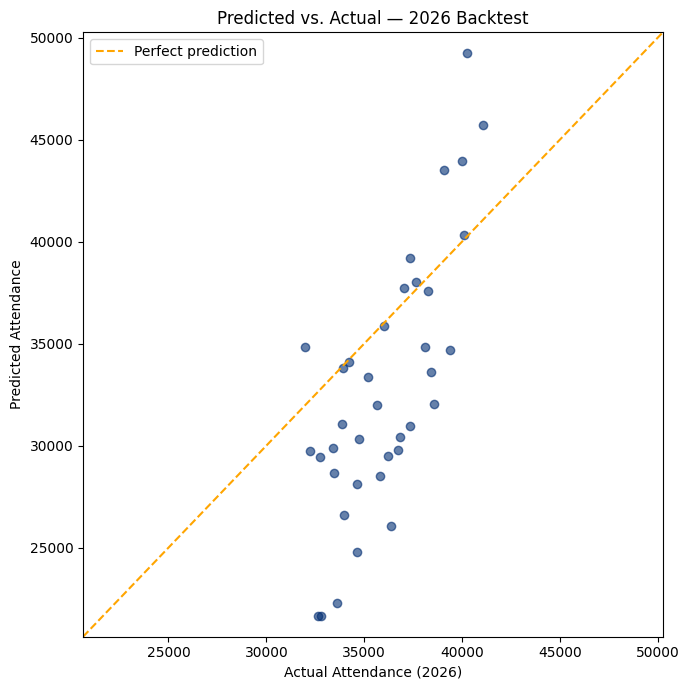

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, test_pred, alpha=0.6, color="#002D72")
lims = [min(y_test.min(), test_pred.min()) - 1000, max(y_test.max(), test_pred.max()) + 1000]
ax.plot(lims, lims, color="orange", linestyle="--", label="Perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual Attendance (2026)")
ax.set_ylabel("Predicted Attendance")
ax.set_title("Predicted vs. Actual — 2026 Backtest")
ax.legend()
plt.tight_layout()
plt.show()

## Coefficients — What's Driving the Model
Each coefficient is the predicted change in attendance for a one-unit increase in that feature, holding everything else constant. Opponent dummies are collapsed into a single "opponent effect" summary (min/max/mean) since there are ~20 of them.

Intercept (baseline attendance, reference opponent): -4,103,234

Non-opponent feature coefficients, strongest first:
mets_win_pct           29441.0
opp_win_pct            -6022.2
is_weekend              3238.4
is_premium_national    -3037.0
season                  2027.3
n_promotions            1996.6
is_bobblehead           1824.1
is_national             1404.7
is_day_game             1049.0
avg_precip_mm           -925.9
month                    678.7
mets_streak_num         -264.6
opp_starter_era          149.1
avg_temp_f               148.5
dayofweek                147.8
is_promo                 -75.2
mets_starter_era          58.8
dtype: float64

Opponent effect range: -2,243 to 15,497 (mean 3,018)
Top 5 opponent draws:
opponent_New York Yankees         15497.0
opponent_Los Angeles Dodgers       9134.0
opponent_Toronto Blue Jays         7849.0
opponent_Philadelphia Phillies     6835.0
opponent_Cleveland Guardians       6050.0
dtype: float64
Bottom 5 opponent draws:
opponent_Kansas

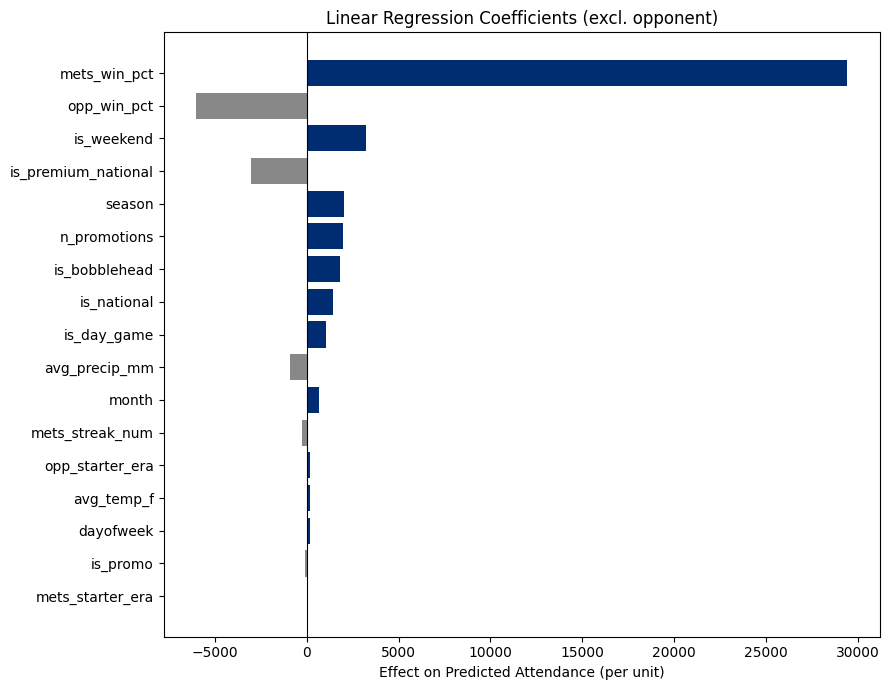

In [6]:
coefs = pd.Series(model.coef_, index=X_train.columns)
opp_coefs = coefs[coefs.index.str.startswith("opponent_")]
non_opp_coefs = coefs[~coefs.index.str.startswith("opponent_")].sort_values(key=abs, ascending=False)

print(f"Intercept (baseline attendance, reference opponent): {model.intercept_:,.0f}\n")
print("Non-opponent feature coefficients, strongest first:")
print(non_opp_coefs.round(1))
print(f"\nOpponent effect range: {opp_coefs.min():,.0f} to {opp_coefs.max():,.0f} (mean {opp_coefs.mean():,.0f})")
print("Top 5 opponent draws:")
print(opp_coefs.sort_values(ascending=False).head(5).round(0))
print("Bottom 5 opponent draws:")
print(opp_coefs.sort_values(ascending=False).tail(5).round(0))

plt.figure(figsize=(9, 7))
colors = ["#002D72" if v > 0 else "#888" for v in non_opp_coefs.values[::-1]]
plt.barh(non_opp_coefs.index[::-1], non_opp_coefs.values[::-1], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Effect on Predicted Attendance (per unit)")
plt.title("Linear Regression Coefficients (excl. opponent)")
plt.tight_layout()
plt.show()

## Per-Game Backtest Detail
Every completed 2026 game the model never trained on, actual vs. predicted.

In [7]:
backtest = test.loc[test_model.index, ["date", "opponent", "attendance"]].copy()
backtest["predicted"] = test_pred
backtest["error"] = backtest["predicted"] - backtest["attendance"]
backtest["abs_pct_error"] = (backtest["error"].abs() / backtest["attendance"] * 100).round(1)
backtest = backtest.sort_values("date")

print(f"Mean absolute % error: {backtest['abs_pct_error'].mean():.1f}%")
print(f"Median absolute % error: {backtest['abs_pct_error'].median():.1f}%")
backtest.round(0)

Mean absolute % error: 13.4%
Median absolute % error: 11.4%


,date,opponent,attendance,predicted,error,abs_pct_error
3,2026-04-07,Arizona Diamondbacks,34753.0,30310.0,-4443.0,13.0
4,2026-04-08,Arizona Diamondbacks,33422.0,29878.0,-3544.0,11.0
5,2026-04-09,Arizona Diamondbacks,35783.0,28495.0,-7288.0,20.0
7,2026-04-11,Athletics,38244.0,37590.0,-654.0,2.0
8,2026-04-12,Athletics,37316.0,30945.0,-6371.0,17.0
9,2026-04-21,Minnesota Twins,32798.0,21636.0,-11162.0,34.0
12,2026-04-24,Colorado Rockies,36233.0,29513.0,-6720.0,18.0
14,2026-04-28,Washington Nationals,33622.0,22283.0,-11339.0,34.0
15,2026-04-29,Washington Nationals,32624.0,21646.0,-10978.0,34.0
16,2026-04-30,Washington Nationals,34621.0,24780.0,-9841.0,28.0


## Training Window Comparison
Mirrors Sean's approach at MLB: team performance swings a lot year to year, so a smaller, more recent training window might track next season better than pooling everything. Compare all-4-seasons vs. 2024-2025 vs. 2025-only, all evaluated against the same 2026 backtest.

In [8]:
def fit_linear_window(seasons_included, label):
    mask = train_model["season"].isin(seasons_included)
    sub = train_encoded[mask]
    X_sub, y_sub = sub.drop(columns=[TARGET]), sub[TARGET]
    m = LinearRegression()
    m.fit(X_sub, y_sub)
    pred = m.predict(X_test)
    metrics = evaluate(y_test, pred)
    print(f"{label:<20} n={len(sub):>4}  R²={metrics['r2']:6.3f}  MAE={metrics['mae']:>8,.0f}  "
          f"RMSE={metrics['rmse']:>8,.0f}  MAPE={metrics['mape']:5.1f}%")
    return {"model": m, "pred": pred, **metrics}

window_results = {}
for seasons_included, label in [([2022, 2023, 2024, 2025], "All 4 seasons"),
                                 ([2024, 2025], "2024-2025 only"),
                                 ([2025], "2025 only")]:
    window_results[label] = fit_linear_window(seasons_included, label)

All 4 seasons        n= 281  R²=-2.058  MAE=   4,773  RMSE=   5,809  MAPE= 13.4%
2024-2025 only       n= 137  R²=-7.108  MAE=   8,264  RMSE=   9,459  MAPE= 22.9%
2025 only            n=  71  R²=-10.065  MAE=   9,962  RMSE=  11,049  MAPE= 28.0%


## Tree-Based Models
Worth the caution flag Sean raised: 281 training rows with 46 features (mostly opponent dummies) is a small, wide dataset for tree ensembles — they can easily fit noise that doesn't generalize, especially to a new season with a real level shift like 2026. Trying them anyway since it's cheap to check, but the linear model remains the one we'd actually explain decisions with.

In [9]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

X_train_full = train_encoded.drop(columns=[TARGET])
y_train_full = train_encoded[TARGET]

tree_results = {}

rf = RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=5, random_state=42)
rf.fit(X_train_full, y_train_full)
rf_pred = rf.predict(X_test)
tree_results["Random Forest"] = {"model": rf, "pred": rf_pred, **evaluate(y_test, rf_pred)}

gbm = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
gbm.fit(X_train_full, y_train_full)
gbm_pred = gbm.predict(X_test)
tree_results["Gradient Boosting"] = {"model": gbm, "pred": gbm_pred, **evaluate(y_test, gbm_pred)}

for label, r in tree_results.items():
    print(f"{label:<20} R²={r['r2']:6.3f}  MAE={r['mae']:>8,.0f}  RMSE={r['rmse']:>8,.0f}  MAPE={r['mape']:5.1f}%")

Random Forest        R²=-0.535  MAE=   3,623  RMSE=   4,115  MAPE= 10.4%
Gradient Boosting    R²= 0.425  MAE=   2,045  RMSE=   2,520  MAPE=  5.8%


## Ensemble & Full Comparison
Simple average of the linear (all 4 seasons), Random Forest, and Gradient Boosting predictions — not a trained meta-model (true stacking), just averaging to see if blending smooths out each model's individual bias. Then every approach side by side.

In [10]:
ensemble_pred = (window_results["All 4 seasons"]["pred"] + rf_pred + gbm_pred) / 3
ensemble_metrics = evaluate(y_test, ensemble_pred)

all_results = {**window_results, **tree_results, "Ensemble (avg of 3)": {"pred": ensemble_pred, **ensemble_metrics}}

summary = pd.DataFrame({
    label: {"R2": r["r2"], "MAE": r["mae"], "RMSE": r["rmse"], "MAPE": r["mape"]}
    for label, r in all_results.items()
}).T.sort_values("MAE")

print("All approaches, evaluated on the same 48-game 2026 backtest, sorted by MAE:")
summary.round(3)

All approaches, evaluated on the same 48-game 2026 backtest, sorted by MAE:


,R2,MAE,RMSE,MAPE
Gradient Boosting,0.425,2044.972,2519.796,5.811
Ensemble (avg of 3),0.452,2164.210,2459.487,6.089
Random Forest,-0.535,3623.343,4115.290,10.388
All 4 seasons,-2.058,4772.621,5808.932,13.392
2024-2025 only,-7.108,8263.817,9458.541,22.915
2025 only,-10.065,9962.307,11049.350,27.971


## Feature Importance Across All Three Model Types
Each model ranks "what matters" differently: linear regression by absolute coefficient size, Random Forest and Gradient Boosting by how much each feature actually reduces prediction error across splits. All three normalized to sum to 1 (relative importance, not tickets) so they're comparable side by side. All ~20 opponent dummies are collapsed into one `opponent (all teams)` row — otherwise they'd dominate the table without telling us much individually.

In [11]:
def grouped_importance(values, feature_names):
    s = pd.Series(values, index=feature_names)
    opp_mask = s.index.str.startswith("opponent_")
    grouped = s[~opp_mask].copy()
    grouped["opponent (all teams)"] = s[opp_mask].sum()
    return grouped / grouped.sum()

linear_model = window_results["All 4 seasons"]["model"]
linear_imp = grouped_importance(np.abs(linear_model.coef_), X_train_full.columns)
rf_imp = grouped_importance(rf.feature_importances_, X_train_full.columns)
gbm_imp = grouped_importance(gbm.feature_importances_, X_train_full.columns)

importance_table = pd.DataFrame({
    "Linear (|coef|, normalized)": linear_imp,
    "Random Forest": rf_imp,
    "Gradient Boosting": gbm_imp,
})
importance_table["avg_rank"] = importance_table.rank(ascending=False).mean(axis=1)
importance_table = importance_table.sort_values("avg_rank").drop(columns="avg_rank")

print("Relative importance by model (each column sums to 1.0), sorted by average rank across all three:")
importance_table.round(3)

Relative importance by model (each column sums to 1.0), sorted by average rank across all three:


,"Linear (|coef|, normalized)",Random Forest,Gradient Boosting
season,0.014,0.347,0.299
opponent (all teams),0.639,0.046,0.187
mets_win_pct,0.203,0.066,0.061
opp_win_pct,0.041,0.079,0.048
is_weekend,0.022,0.052,0.034
avg_temp_f,0.001,0.131,0.119
dayofweek,0.001,0.118,0.096
is_national,0.010,0.024,0.019
opp_starter_era,0.001,0.030,0.024
n_promotions,0.014,0.011,0.017


## Naive Baseline Comparisons
Standard R² compares a model to the test set's *own* mean — which quietly assumes you already know the answer. Four honest baselines instead, each using only information that would actually be available before 2026 started:
1. **Historical mean** — average attendance across all of 2022-2025
2. **Last year's average** — 2025's average attendance only (captures recent trend for free)
3. **Same matchup last year** — that specific opponent's average home-game attendance in 2025 (falls back to that opponent's all-time training average, then the overall historical mean, if they didn't visit in 2025)
4. **Same weekday/month average** — historical average attendance for that month + day-of-week combination

If a model can't beat these, it isn't adding real value over a five-minute spreadsheet lookup.

In [12]:
# 1. Historical mean (2022-2025) — already computed at the top of the notebook
baseline_historical = pd.Series(historical_mean, index=test_model.index)

# 2. Last year's average (2025 only)
avg_2025 = train.loc[train["season"] == 2025, "attendance"].mean()
baseline_last_year = pd.Series(avg_2025, index=test_model.index)

# 3. Same matchup last year — that opponent's 2025 home-game average, falling back to
#    their all-time training average, then the overall historical mean
matchup_2025 = train.loc[train["season"] == 2025].groupby("opponent")["attendance"].mean()
matchup_alltime = train.groupby("opponent")["attendance"].mean()

def matchup_baseline(opponent):
    if opponent in matchup_2025.index:
        return matchup_2025[opponent]
    if opponent in matchup_alltime.index:
        return matchup_alltime[opponent]
    return historical_mean

baseline_matchup = test_model["opponent"].map(matchup_baseline)

# 4. Same weekday/month average
calendar_avg = train.groupby(["month", "dayofweek"])["attendance"].mean()

def calendar_baseline(row):
    key = (row["month"], row["dayofweek"])
    return calendar_avg.get(key, historical_mean)

baseline_calendar = test_model.apply(calendar_baseline, axis=1)

print(f"Historical mean (2022-2025):  {historical_mean:,.0f}")
print(f"Last year's average (2025):   {avg_2025:,.0f}")
print(f"Same matchup last year:       {baseline_matchup.min():,.0f} - {baseline_matchup.max():,.0f} (varies by opponent)")
print(f"Same weekday/month average:   {baseline_calendar.min():,.0f} - {baseline_calendar.max():,.0f} (varies by date)")

Historical mean (2022-2025):  33,876
Last year's average (2025):   39,776
Same matchup last year:       15,936 - 42,659 (varies by opponent)
Same weekday/month average:   25,688 - 38,327 (varies by date)


## Final Comparison: Every Model vs. Every Baseline
R² here is computed against the historical-mean baseline specifically (not the test set's own mean), so a positive value means genuinely earned skill over the simplest honest guess.

In [13]:
all_predictions = {
    "Baseline: Historical Mean (2022-2025)": baseline_historical,
    "Baseline: Last Year's Avg (2025)": baseline_last_year,
    "Baseline: Same Matchup Last Year": baseline_matchup,
    "Baseline: Same Weekday/Month Avg": baseline_calendar,
    "Linear (all 4 seasons)": window_results["All 4 seasons"]["pred"],
    "Random Forest": rf_pred,
    "Gradient Boosting": gbm_pred,
    "Ensemble (avg of 3)": ensemble_pred,
}

final_table = pd.DataFrame({
    label: evaluate(y_test, pred)
    for label, pred in all_predictions.items()
}).T.sort_values("mae")
final_table.columns = ["R2_vs_historical_mean", "MAE", "RMSE", "MAPE"]

print("Every model and naive baseline, evaluated on the same 2026 backtest, sorted by MAE:")
final_table.round(3)

Every model and naive baseline, evaluated on the same 2026 backtest, sorted by MAE:


,R2_vs_historical_mean,MAE,RMSE,MAPE
Gradient Boosting,0.425,2044.972,2519.796,5.811
Ensemble (avg of 3),0.452,2164.210,2459.487,6.089
Baseline: Historical Mean (2022-2025),0.000,2627.020,3321.733,6.968
Random Forest,-0.535,3623.343,4115.290,10.388
Baseline: Last Year's Avg (2025),-0.818,3839.753,4479.201,11.138
Baseline: Same Weekday/Month Avg,-0.919,3877.112,4601.104,10.787
Linear (all 4 seasons),-2.058,4772.621,5808.932,13.392
Baseline: Same Matchup Last Year,-4.040,5668.668,7457.007,16.206
